<a href="https://colab.research.google.com/github/HamzaEric/Pet_Breed_Classification/blob/main/Notebooks/Deeper_CNN__Architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
import copy
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# **Reload Data & Baseline Model**

In this notebook, we compare multiple CNN architectures (Baseline, LeNet-like, AlexNet-mini).  
To ensure **self-containment**, we **reload the dataset and baseline model weights**

**Key Points:**

- **Dataset:** Oxford-IIIT Pets (37 breeds), resized to **128×128**, normalized to `[-1,1]` (mean/std ≈ 0.5).
- **Splits:**
  - Training/Validation: 80/20 split from `trainval`.
  - Test: Provided separately.
- **Device:** CPU-only.
- **Baseline Model:** Reload weights trained in NB02 for direct comparison.

In [2]:
device = 'cpu'

IMG_SIZE = 128

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # scale to [-1,1]
])

data_path = "./data/"

trainval_dataset = datasets.OxfordIIITPet(
    root=data_path,
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

test_dataset = datasets.OxfordIIITPet(
    root=data_path,
    split="test",
    target_types="category",
    transform=transform,
    download=True
)

val_ratio = 0.2
train_size = int((1 - val_ratio) * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size

train_dataset, val_dataset = random_split(
    trainval_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # ensure reproducibility
)


BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Confirm splits
print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Number of classes: {len(trainval_dataset.classes)}")

# -----------------------------
# Baseline CNN Definition (same as NB02)
# -----------------------------
class PetCNN(nn.Module):
    def __init__(self):
        super(PetCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # 3x128x128 -> 16x128x128
        self.pool = nn.MaxPool2d(2, 2)                            # -> 16x64x64
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # -> 32x64x64
        self.fc1 = nn.Linear(32 * 32 * 32, 128)                   # -> 128
        self.fc2 = nn.Linear(128, 37)                             # -> 37 (classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> 16x64x64
        x = self.pool(F.relu(self.conv2(x)))   # -> 32x32x32
        x = x.view(-1, 32 * 32 * 32)           # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate and load baseline weights (map to CPU)
baseline_model = PetCNN().to(device)
baseline_model.load_state_dict(torch.load("petcnn_best.pth", map_location=device, weights_only=False))

print("Baseline CNN loaded successfully (CPU-only). Ready for comparison.")


100%|██████████| 792M/792M [00:42<00:00, 18.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.8MB/s]


Train size: 2944
Validation size: 736
Test size: 3669
Number of classes: 37
Baseline CNN loaded successfully (CPU-only). Ready for comparison.


### **3. Architectural Variants Overview (Concept)**

In this notebook, we **compare architectures** to explore how **depth and design choices** affect performance and parameter efficiency.

**Architectures We’ll Compare**

1. **Baseline CNN (NB02)**  
   - 2 convolution layers (3×3) + 2 fully connected layers.  
   - Designed for teaching fundamentals; very shallow.

2. **LeNet-like CNN (1998)**  
   - Classic architecture for MNIST digit recognition.  
   - 3 convolution layers + 2 fully connected layers.  
   - Slightly deeper; captures more **mid-level features** (edges → textures).

3. **AlexNet-mini (2012) / VGG-lite**  
   - Inspired by ImageNet-winning networks.  
   - 4–5 convolution layers + deeper FC layers.  
   - Captures **hierarchical features** (edges → textures → object parts → objects).

**High-Level ASCII Diagrams**

**(a) Baseline CNN (NB02)**

```text
Input (3×128×128)
│
├── Conv(3→16) → ReLU → MaxPool(2×2)
│
├── Conv(16→32) → ReLU → MaxPool(2×2)
│
├── Flatten → FC(32×32×32 → 128) → ReLU
│
└── FC(128 → 37) → Softmax
```

**(b) LeNet-like CNN**

```text
Input (3×128×128)
│
├── Conv(3→16) → ReLU → MaxPool(2×2)
│
├── Conv(16→32) → ReLU → MaxPool(2×2)
│
├── Conv(32→64) → ReLU → MaxPool(2×2)
│
├── Flatten → FC(64×16×16 → 256) → ReLU
│
└── FC(256 → 37) → Softmax
```

**(c) AlexNet-mini / VGG-lite**

```text
Input (3×128×128)
│
├── Conv(3→32) → ReLU → Conv(32→32) → ReLU → MaxPool(2×2)
│
├── Conv(32→64) → ReLU → Conv(64→64) → ReLU → MaxPool(2×2)
│
├── Conv(64→128) → ReLU → MaxPool(2×2)
│
├── Flatten → FC(128×16×16 → 512) → ReLU → Dropout
│
└── FC(512 → 37) → Softmax

```

**Parameter Count and Shape Transformations**

| Layer Type    | Baseline CNN                  | LeNet-like           | AlexNet-mini          |
|---------------|-------------------------------|----------------------|-----------------------|
| **Conv Layers** | Few params ($3\times3$ filters) | More filters (16→64) | Many filters (32→128) |
| **FC Layers**   | Dominant ($32k \to 128$)       | Moderate ($64\times16\times16 \to 256$) | Larger ($128\times16\times16 \to 512$) |
| **Total Params**| ~ 4$M                      | ~ 6$M            | ~ 10$–$12$M       |

**Receptive Field Expansion**

- **Baseline CNN**: Each neuron “sees” only small local patches.
- **LeNet-like**: Deeper layers combine local features → larger effective receptive field.
- **AlexNet-mini**: Stacks more conv layers; receptive field covers most of the image, capturing global context (e.g., full face of a dog).




In [3]:
# -------------------------------
# 1. Baseline CNN (for reference)
# -------------------------------
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # 3x128x128 -> 16x128x128
        self.pool = nn.MaxPool2d(2, 2)                            # Halve H,W
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 16x64x64 -> 32x64x64
        self.fc1 = nn.Linear(32 * 32 * 32, 128)                   # 32x32x32 -> 128
        self.fc2 = nn.Linear(128, 37)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # -> 16x64x64
        x = self.pool(F.relu(self.conv2(x)))  # -> 32x32x32
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# -------------------------------
# 2. LeNet-like CNN (3 conv layers)
# -------------------------------
class LeNetLikeCNN(nn.Module):
    def __init__(self):
        super(LeNetLikeCNN, self).__init__()
        # Conv Layer 1: 3 → 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)    # 3x128x128 -> 16x128x128
        # Conv Layer 2: 16 → 32
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)   # 16x64x64 -> 32x64x64
        # Conv Layer 3: 32 → 64
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)   # 32x32x32 -> 64x32x32
        self.pool = nn.MaxPool2d(2, 2)

        # After 3 poolings: 128 -> 64 -> 32 -> 16
        # Final feature map: 64 x 16 x 16 = 16384
        self.fc1 = nn.Linear(64 * 16 * 16, 256)  # Fully connected layer
        self.fc2 = nn.Linear(256, 37)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> 16x64x64
        x = self.pool(F.relu(self.conv2(x)))   # -> 32x32x32
        x = self.pool(F.relu(self.conv3(x)))   # -> 64x16x16
        x = x.view(x.size(0), -1)              # Flatten: 64*16*16 = 16384
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# -------------------------------
# 3. AlexNet-mini CNN (5 conv layers)
# -------------------------------
class AlexNetMini(nn.Module):
    def __init__(self):
        super(AlexNetMini, self).__init__()
        # Conv Layer 1: 3 → 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)     # 3x128x128 -> 32x128x128
        # Conv Layer 2: 32 → 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)    # 32x64x64 -> 64x64x64
        # Conv Layer 3: 64 → 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)   # 64x32x32 -> 128x32x32
        # Conv Layer 4: 128 → 128
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)  # 128x16x16 -> 128x16x16
        # Conv Layer 5: 128 → 256
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)  # 128x8x8 -> 256x8x8
        self.pool = nn.MaxPool2d(2, 2)

        # After 5 conv + 5 pool layers:
        # 128 -> 64 -> 32 -> 16 -> 8 -> 4 (but here last pooling is applied after conv5)
        # Final feature map: 256 x 4 x 4 = 4096
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 37)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> 32x64x64
        x = self.pool(F.relu(self.conv2(x)))   # -> 64x32x32
        x = self.pool(F.relu(self.conv3(x)))   # -> 128x16x16
        x = self.pool(F.relu(self.conv4(x)))   # -> 128x8x8
        x = self.pool(F.relu(self.conv5(x)))   # -> 256x4x4
        x = x.view(x.size(0), -1)              # Flatten: 256*4*4 = 4096
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [4]:
# Accuracy calculation helper
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return (preds == labels).sum().item() / len(labels)

# Training function (CPU-only)
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=5, device='cpu'):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    model.to(device)

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print('-' * 20)

        # Train and validation phases
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader

            running_loss = 0.0
            running_corrects = 0
            total_samples = 0

            for inputs, labels in loader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (outputs.argmax(1) == labels).sum().item()
                total_samples += labels.size(0)

            epoch_loss = running_loss / total_samples
            epoch_acc = running_corrects / total_samples

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc)
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc)

                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    print(f"Best val loss: {best_loss:.4f}")

    # Load best weights
    model.load_state_dict(best_model_wts)

    return model, (train_losses, val_losses, train_accuracies, val_accuracies)


In [5]:
# parameter count
def count_params(model):
    return sum(p.numel() for p in model.parameters())

# Instantiate models
baseline_model = BaselineCNN()
lenet_model = LeNetLikeCNN()
alexmini_model = AlexNetMini()

# Print parameter counts
print(f"BaselineCNN parameters: {count_params(baseline_model):,}")
print(f"LeNetLikeCNN parameters: {count_params(lenet_model):,}")
print(f"AlexNetMini parameters: {count_params(alexmini_model):,}")

# Define common loss and optimizer settings
criterion = nn.CrossEntropyLoss()

# Train Baseline
print("\n= Training Baseline CNN (we are using pre-trainned models) =")
# Train LeNet-like
print("\n= Training LeNet-like CNN (we are using pre-trainned models) =")
# Train AlexNet-mini
print("\n= Training AlexNet-mini CNN (we are using pre-trainned models) =")

BaselineCNN parameters: 4,204,293
LeNetLikeCNN parameters: 4,227,653
AlexNetMini parameters: 2,652,645

= Training Baseline CNN (we are using pre-trainned models) =

= Training LeNet-like CNN (we are using pre-trainned models) =

= Training AlexNet-mini CNN (we are using pre-trainned models) =


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

learning_rate = 0.001
optimizer_baseline = optim.Adam(baseline_model.parameters(), lr=learning_rate)
optimizer_lenet = optim.Adam(lenet_model.parameters(), lr=learning_rate)
optimizer_alex = optim.Adam(alexmini_model.parameters(), lr=learning_rate)

print("\n= Training Baseline CNN =")
baseline_model, baseline_history = train_model(
    model=baseline_model,
    criterion=criterion,
    optimizer=optimizer_baseline,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=10,
    device=device
)

print("\n= Training LeNet-like CNN =")
lenet_model, lenet_history = train_model(
    model=lenet_model,
    criterion=criterion,
    optimizer=optimizer_lenet,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=10,
    device=device
)

print("\n= Training AlexNet-mini CNN =")
alexmini_model, alex_history = train_model(
    model=alexmini_model,
    criterion=criterion,
    optimizer=optimizer_alex,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=10,
    device=device
)

Training on device: cuda

= Training Baseline CNN =
Epoch 1/10
--------------------
Train Loss: 3.5910 Acc: 0.0380
Val Loss: 3.4984 Acc: 0.0543
Epoch 2/10
--------------------
Train Loss: 3.3790 Acc: 0.0914
Val Loss: 3.3347 Acc: 0.0856
Epoch 3/10
--------------------
Train Loss: 2.8774 Acc: 0.2116
Val Loss: 3.2945 Acc: 0.1168
Epoch 4/10
--------------------
Train Loss: 1.7994 Acc: 0.4935
Val Loss: 3.9690 Acc: 0.1359
Epoch 5/10
--------------------
Train Loss: 0.5913 Acc: 0.8356
Val Loss: 5.3930 Acc: 0.1318
Epoch 6/10
--------------------
Train Loss: 0.0919 Acc: 0.9806
Val Loss: 6.5730 Acc: 0.1304
Epoch 7/10
--------------------
Train Loss: 0.0159 Acc: 0.9980
Val Loss: 7.7913 Acc: 0.1304
Epoch 8/10
--------------------
Train Loss: 0.0033 Acc: 0.9997
Val Loss: 8.1653 Acc: 0.1372
Epoch 9/10
--------------------
Train Loss: 0.0388 Acc: 0.9898
Val Loss: 7.3043 Acc: 0.1168
Epoch 10/10
--------------------
Train Loss: 0.0389 Acc: 0.9901
Val Loss: 8.1047 Acc: 0.1304
Training complete in 2m 49s

In [14]:
def evaluate_model(model, loader, device=device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return acc

# Evaluate all three models
baseline_acc = evaluate_model(baseline_model, test_loader)
lenet_acc = evaluate_model(lenet_model, test_loader)
alexmini_acc = evaluate_model(alexmini_model, test_loader)

print(f"Baseline CNN Test Accuracy: {baseline_acc:.4f}")
print(f"LeNet-like CNN Test Accuracy: {lenet_acc:.4f}")
print(f"AlexNet-mini CNN Test Accuracy: {alexmini_acc:.4f}")

# Parameter counts
baseline_params = count_params(baseline_model)
lenet_params = count_params(lenet_model)
alexmini_params = count_params(alexmini_model)

# Compare parameter count vs accuracy
print("\nParameter vs Accuracy Comparison:")
print(f"Baseline: {baseline_params:,} params → {baseline_acc:.2%}")
print(f"LeNet-like: {lenet_params:,} params → {lenet_acc:.2%}")
print(f"AlexNet-mini: {alexmini_params:,} params → {alexmini_acc:.2%}")

Baseline CNN Test Accuracy: 0.1022
LeNet-like CNN Test Accuracy: 0.1183
AlexNet-mini CNN Test Accuracy: 0.0984

Parameter vs Accuracy Comparison:
Baseline: 4,204,293 params → 10.22%
LeNet-like: 4,227,653 params → 11.83%
AlexNet-mini: 2,652,645 params → 9.84%


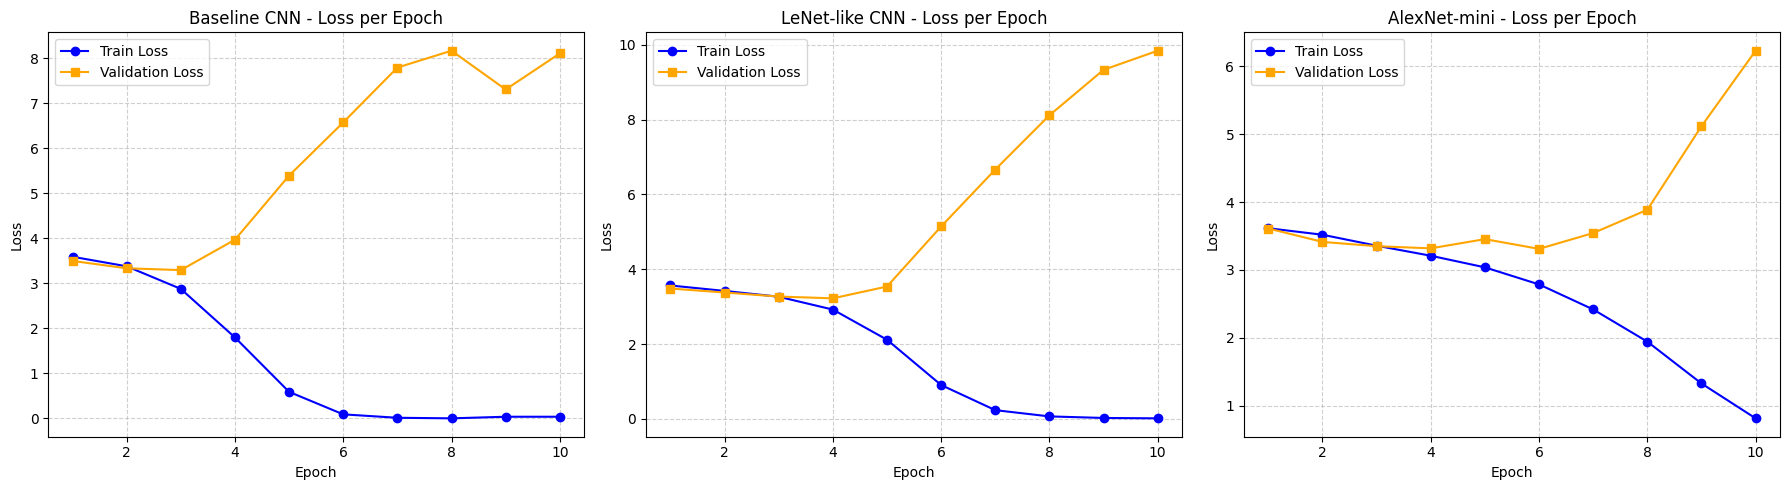

In [15]:
import matplotlib.pyplot as plt

# Group the histories and names for easy looping
model_data = [
    ('Baseline CNN', baseline_history),
    ('LeNet-like CNN', lenet_history),
    ('AlexNet-mini', alex_history)
]

# Create a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, history) in zip(axes, model_data):
    # Unpack the history tuple
    train_losses, val_losses, train_acc, val_acc = history

    # Create an x-axis for the epochs (1 through 10)
    epochs = range(1, len(train_losses) + 1)

    # Plot the lines
    ax.plot(epochs, train_losses, label='Train Loss', marker='o', color='blue')
    ax.plot(epochs, val_losses, label='Validation Loss', marker='s', color='orange')

    # Formatting
    ax.set_title(f'{name} - Loss per Epoch')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

# Adjust layout and display
plt.tight_layout()
plt.show()

In [18]:
def get_all_predictions(model, test_loader, device='cpu'):
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # Move predictions back to the CPU and convert to standard numpy arrays
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# Extract predictions using your preferred device variable
true_labels, predicted_labels = get_all_predictions(alexmini_model, test_loader, device=device)